<a href="https://colab.research.google.com/github/vikashkumar/Gen-Agentic-AI/blob/main/CNN_Drone_Tutorial_Simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚁 Teaching a Drone to See

### A hands-on, no-maths introduction for industry professionals

---

### 📖 The story

> Your company flies **surveillance drones** over a port, a highway or a large factory site.
> Every drone sends back **thousands of pictures every hour** — far too many for people to watch.
>
> The operations manager asks: **"Can the drone tell us *what* it is looking at, and warn us when something matters?"**

Here is how we turn that business question into something a computer can solve:

```
 🚁 Drone monitoring     "Watch the site 24×7"
        ↓
 🔍 Object recognition   "What objects are in this picture?"
        ↓
 🏷️ Classification       "This small picture shows a … truck? ship? bird?"
        ↓
 📦 CIFAR-10             60,000 small labelled pictures to learn from
        ↓
 🧠 CNN                  The type of AI model that learns to recognise pictures
        ↓
 🚨 Decision             Alert the control room, or just log it
```


### How to use this notebook
- Run the cells **in order, top to bottom** (`Shift + Enter`).
- You do **not** need to understand every line of code. Every line has a comment, and every result has a **🔎 What to look for** box underneath.
- 💡 In Google Colab, first choose `Runtime → Change runtime type → T4 GPU`. Training then takes only a couple of minutes.

---
## 0. Setup

Run this cell first. It loads the tools we need.

In [ ]:
import time                                    # Lets us time how long training takes.
import os                                      # Lets us check whether a saved model file exists.
import numpy as np                             # NumPy: works with grids of numbers (which is what images are).
import matplotlib.pyplot as plt                # Matplotlib: draws pictures and charts.
import torch                                   # PyTorch: the deep-learning library we use to build the CNN.
import torch.nn as nn                          # Ready-made building blocks for neural networks (layers).
import torch.nn.functional as F                # Extra operations such as softmax and convolution.
import torchvision.transforms.functional as TF # Picture effects (blur) to simulate bad flying conditions.
from torchvision import datasets               # Gives us easy access to the CIFAR-10 picture collection.

torch.manual_seed(42)                          # Fix the random starting point so everyone gets similar results.
np.random.seed(42)                             # Same for NumPy's random numbers.

device = 'cuda' if torch.cuda.is_available() else 'cpu'  # Use the fast GPU if available, otherwise the normal CPU.

print("✅ Tools loaded")                       # Confirm the imports worked.
print(f"   Running on: {device.upper()}")     # CUDA = GPU (fast), CPU = slower but still works.

✅ Tools loaded
   Running on: CUDA


### 🔎 What to look for
- `Running on: CUDA` → the GPU is on and training will be fast.
- `Running on: CPU` → it still works, the notebook will automatically use a smaller amount of data.

---
## 1. How does a computer see a picture?  ⏱ 5 min

Before a drone can recognise a truck, we must understand one simple fact:

> **To a computer, every picture is just a grid of numbers.**

### 1.1 Black & white pictures

The simplest picture is a grid of `0`s and `1`s: `0` = black, `1` = white.
The grid below spells the letter **F**.

What the computer stores:
[[0 0 0 0 0 0 0 0]
 [0 1 1 1 1 1 0 0]
 [0 1 0 0 0 0 0 0]
 [0 1 1 1 1 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


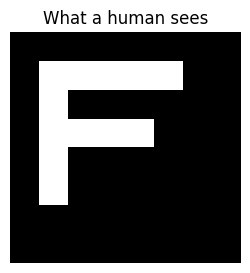

In [ ]:
bw = np.array([                    # Build an 8×8 grid of numbers = an 8×8 pixel picture.
    [0, 0, 0, 0, 0, 0, 0, 0],      # Row 1: all black.
    [0, 1, 1, 1, 1, 1, 0, 0],      # Row 2: white pixels draw the top bar of the F.
    [0, 1, 0, 0, 0, 0, 0, 0],      # Row 3: one white pixel continues the upright line.
    [0, 1, 1, 1, 1, 0, 0, 0],      # Row 4: white pixels draw the middle bar of the F.
    [0, 1, 0, 0, 0, 0, 0, 0],      # Row 5: upright line continues.
    [0, 1, 0, 0, 0, 0, 0, 0],      # Row 6: upright line continues.
    [0, 0, 0, 0, 0, 0, 0, 0],      # Row 7: all black.
    [0, 0, 0, 0, 0, 0, 0, 0],      # Row 8: all black.
])

print("What the computer stores:")  # Label for the printed grid.
print(bw)                           # Print the raw numbers.

plt.figure(figsize=(3, 3))                    # Small square drawing area.
plt.imshow(bw, cmap='gray', vmin=0, vmax=1)   # Draw the grid: 0 → black, 1 → white.
plt.title("What a human sees")                # Title above the picture.
plt.axis('off')                               # Hide the axis ticks.
plt.show()                                    # Display it.

### 🔎 What to look for
- The **numbers** and the **picture** are the same thing, shown two ways.
- ✏️ *Try it:* change some `0`s to `1`s and re-run the cell to draw your own shape.

### 1.2 Grayscale pictures

Real pictures have **shades of grey**. Each pixel is now a number from **0 (black) to 255 (white)**.

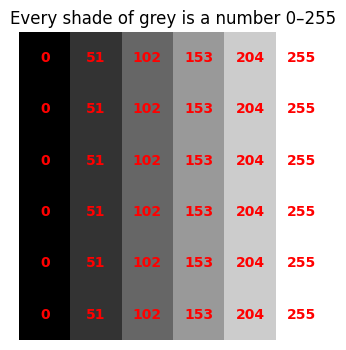

In [ ]:
gradient = np.tile(np.linspace(0, 255, 6).astype(int), (6, 1))  # A 6×6 grid going from dark (left) to bright (right).

plt.figure(figsize=(4, 4))                              # Drawing area.
plt.imshow(gradient, cmap='gray', vmin=0, vmax=255)     # Draw the grid with 0 = black and 255 = white.
for r in range(6):                                      # For every row…
    for c in range(6):                                  # …and every column…
        plt.text(c, r, gradient[r, c], ha='center', va='center',   # …write the pixel's number on top of it.
                 color='red', fontsize=10, fontweight='bold')       # In bold red so it is easy to read.
plt.title("Every shade of grey is a number 0–255")      # Title.
plt.axis('off')                                         # Hide the axis ticks.
plt.show()                                              # Display it.

### 🔎 What to look for
- Small numbers are **dark**, big numbers are **bright**.
- A grayscale camera simply measures "how much light" hit each pixel.

### 1.3 Colour pictures

A colour picture is **three grayscale grids stacked together**: one for **Red**, one for **Green**, one for **Blue** (RGB).
Every colour you see on a screen is a mix of these three.

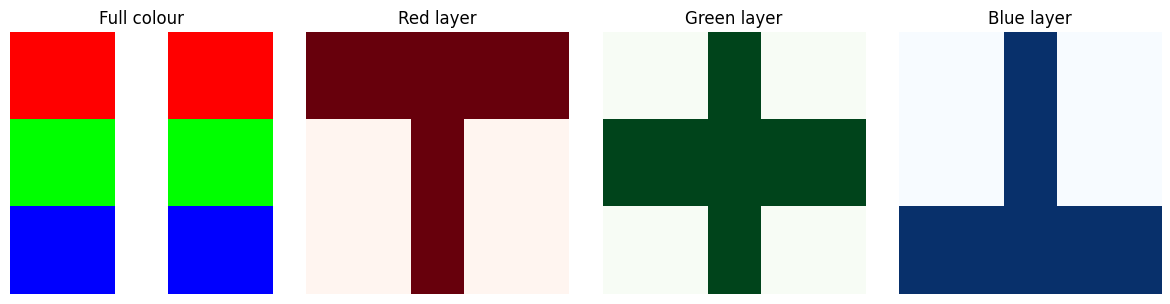

Shape (height, width, colour layers): (30, 30, 3)
Numbers needed to store this picture : 2700


In [ ]:
flag = np.zeros((30, 30, 3), dtype=np.uint8)  # A 30×30 picture with 3 colour layers, all 0 (black) to start.
flag[:10, :, 0] = 255                          # Top third: Red layer at full strength → red stripe.
flag[10:20, :, 1] = 255                        # Middle third: Green layer at full strength → green stripe.
flag[20:, :, 2] = 255                          # Bottom third: Blue layer at full strength → blue stripe.
flag[:, 12:18, :] = 255                        # A vertical band with ALL three layers at 255 → white.

fig, axes = plt.subplots(1, 4, figsize=(12, 3))  # Four panels side by side.
axes[0].imshow(flag)                             # The full colour picture.
axes[0].set_title("Full colour")                 # Label.
for i, (name, cmap) in enumerate([('Red', 'Reds'), ('Green', 'Greens'), ('Blue', 'Blues')]):  # Loop over the 3 layers.
    axes[i + 1].imshow(flag[:, :, i], cmap=cmap, vmin=0, vmax=255)  # Show one layer on its own.
    axes[i + 1].set_title(f"{name} layer")       # Label the layer.
for ax in axes:                                  # Tidy up every panel…
    ax.axis('off')                               # …by hiding the axis ticks.
plt.tight_layout()                               # Avoid overlapping titles.
plt.show()                                       # Display it.

print("Shape (height, width, colour layers):", flag.shape)  # 30 × 30 × 3.
print("Numbers needed to store this picture :", flag.size)  # 30 × 30 × 3 = 2,700 numbers.

### 🔎 What to look for
- The **white band** appears bright in **all three** layers: white = red + green + blue at full strength.
- Even a tiny 30×30 colour picture needs **2,700 numbers**. A single full-HD drone frame needs about **6 million**.
- So the real question is: **how can a computer find a "truck" inside millions of numbers?** That is what a CNN learns to do.

---
## 2. Our data: CIFAR-10

A real drone system works in two steps:
1. A **detector** draws a box around every object in the drone's picture.
2. Each box is cut out, shrunk to a small picture, and a **classifier** says what it is. ← *we build this today*

Collecting and labelling our own drone pictures would take weeks. So, like most real projects, we **start with a public dataset that looks similar**.

**CIFAR-10** has 60,000 small colour pictures (32×32 pixels) in 10 categories — very similar to the small cut-outs a drone's detector produces:

✈️ airplane · 🚗 automobile · 🐦 bird · 🐱 cat · 🦌 deer · 🐶 dog · 🐸 frog · 🐴 horse · 🚢 ship · 🚚 truck

In [ ]:
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',   # The 10 categories, in the order
               'dog', 'frog', 'horse', 'ship', 'truck']           # CIFAR-10 numbers them (0 to 9).

# What does each category mean for the drone's operations team?
DRONE_ACTION = {
    'airplane':   'ALERT',   # Something in our airspace → warn the control room.
    'automobile': 'ALERT',   # Vehicle in a monitored zone → warn.
    'truck':      'ALERT',   # Vehicle in a monitored zone → warn.
    'ship':       'ALERT',   # Boat near the port / coastline → warn.
    'bird':       'log',     # Animals → just record it, no need to disturb anyone.
    'cat':        'log',
    'deer':       'log',
    'dog':        'log',
    'frog':       'log',
    'horse':      'log',
}

# --- Download the pictures (about 170 MB, only the first time) ---
train_set = datasets.CIFAR10('./data', train=True,  download=True)  # 50,000 pictures for LEARNING.
test_set  = datasets.CIFAR10('./data', train=False, download=True)  # 10,000 NEW pictures for TESTING.

# --- Turn the pictures into numbers the CNN can use ---
MEAN = torch.tensor([0.49, 0.48, 0.45]).view(1, 3, 1, 1)  # Average brightness of each colour layer in CIFAR-10.
STD  = torch.tensor([0.25, 0.24, 0.26]).view(1, 3, 1, 1)  # How much brightness typically varies per layer.

def prepare(dataset, limit=None):                          # Convert a whole dataset into one big block of numbers.
    pics = torch.tensor(dataset.data[:limit])               # All pictures: (count, 32, 32, 3) numbers from 0–255.
    labels = torch.tensor(dataset.targets[:limit])          # The correct category number (0–9) of each picture.
    pics = pics.permute(0, 3, 1, 2).float() / 255           # Reorder to (count, 3, 32, 32) as PyTorch expects; scale to 0–1.
    pics = (pics - MEAN) / STD                              # Centre the numbers around 0 → the CNN learns faster.
    return pics.to(device), labels.to(device)               # Put everything on the GPU ONCE → training is much faster.

LIMIT = None if device == 'cuda' else 10_000               # Use all 50,000 on a GPU; only 10,000 on a CPU to save time.
X_train, y_train = prepare(train_set, LIMIT)                # Pictures and answers the CNN learns from.
X_test,  y_test  = prepare(test_set, None if device == 'cuda' else 2_000)  # Pictures the CNN has never seen.

print(f"Pictures to learn from : {len(y_train):,}")        # How many training pictures we use.
print(f"Pictures to test on    : {len(y_test):,}")         # How many test pictures we use.
print(f"One batch of data shape: {tuple(X_train.shape)}  → (pictures, colour layers, height, width)")

100%|██████████| 170M/170M [04:39<00:00, 610kB/s]


Pictures to learn from : 50,000
Pictures to test on    : 10,000
One batch of data shape: (50000, 3, 32, 32)  → (pictures, colour layers, height, width)


### 🔎 What to look for
- **Learning pictures** and **test pictures** are kept separate. The test pictures play the role of *next week's drone footage*: the model never sees them while learning, so they tell us honestly how it will perform.
- The shape `(50000, 3, 32, 32)` is exactly what we learned in Section 1: lots of pictures × 3 colour layers × 32 × 32 pixels.

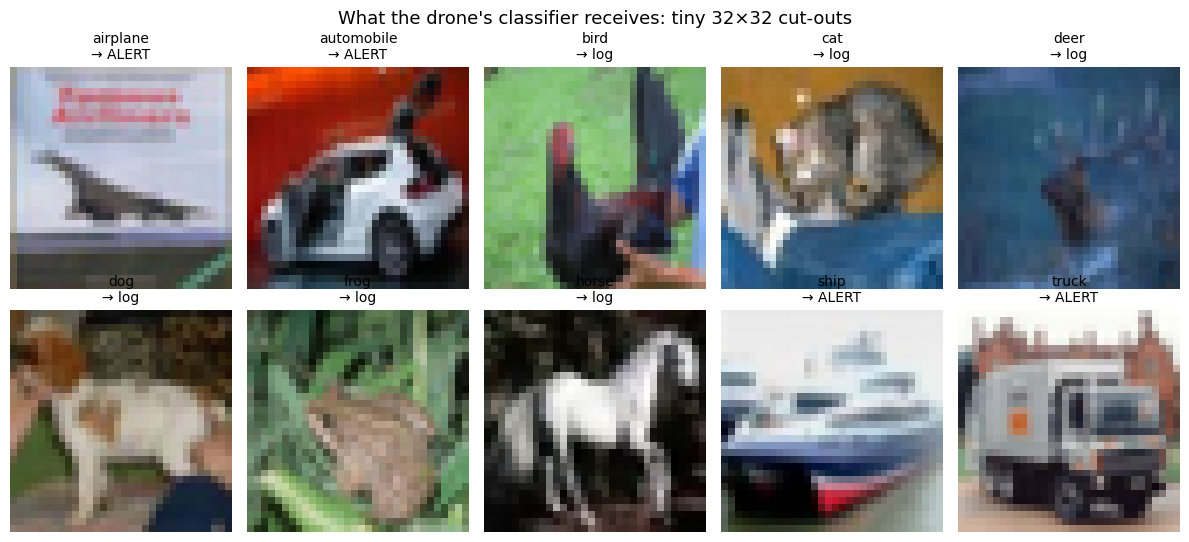

In [ ]:
def show(pic):                                           # Helper: turn the CNN's numbers back into a viewable picture.
    pic = pic.cpu() * STD[0] + MEAN[0]                   # Undo the centring we did above.
    return pic.permute(1, 2, 0).clamp(0, 1).numpy()      # Reorder to (height, width, colour) for drawing; keep values in 0–1.

fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))        # A 2×5 grid: one picture per category.
for c, ax in enumerate(axes.flat):                       # Go through categories 0 to 9.
    first = (y_test == c).nonzero()[0, 0]                # Position of the first test picture of this category.
    ax.imshow(show(X_test[first]))                       # Draw it.
    ax.set_title(f"{CLASS_NAMES[c]}\n→ {DRONE_ACTION[CLASS_NAMES[c]]}", fontsize=10)  # Name + what the drone should do.
    ax.axis('off')                                       # Hide the axis ticks.
plt.suptitle("What the drone's classifier receives: tiny 32×32 cut-outs", fontsize=13)  # Overall title.
plt.tight_layout()                                       # Avoid overlaps.
plt.show()                                               # Display it.

### 🔎 What to look for
- The pictures are **tiny and blurry** — that is realistic: a car seen from 100 m up really is only a few dozen pixels.
- Under each picture is the **business action**: vehicles, ships and aircraft → **ALERT**; animals → **log** only.
- 💬 Ask the room: *which categories do you think the AI will confuse?* (Common answers: cat/dog, car/truck, airplane/bird.)

---
## 3. What does a CNN actually do?

A **CNN (Convolutional Neural Network)** looks at a picture through many small **filters**.
A filter is a tiny 3×3 window of numbers that slides across the picture and lights up when it finds a particular pattern — for example an **edge**.

Below we apply two edge-finding filters **that we wrote by hand**. A CNN does the same thing, but it **learns its own filters** — hundreds of them — from the examples.

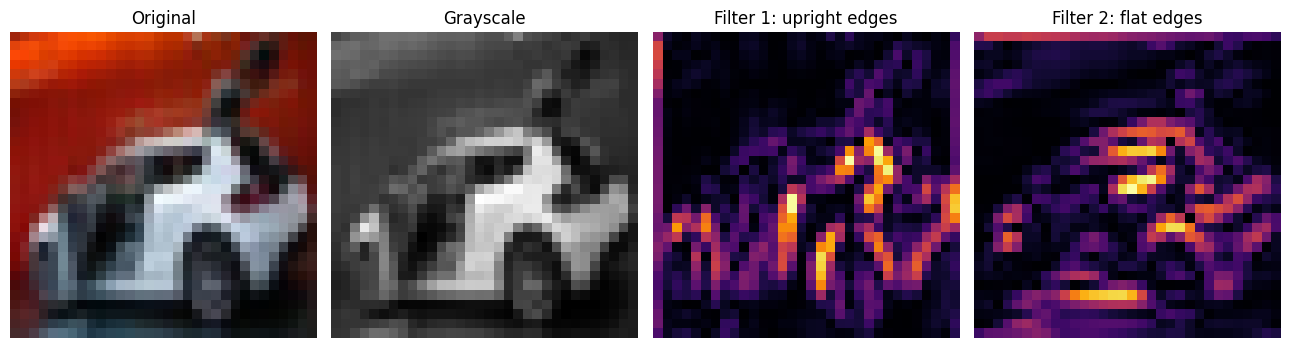

In [ ]:
car = X_test[(y_test == 1).nonzero()[0, 0]]          # Take our example 'automobile' picture.
gray = show(car).mean(axis=2)                         # Average the 3 colour layers → one grayscale grid.
x = torch.tensor(gray, dtype=torch.float32)[None, None]  # Add two extra dimensions: shape (1, 1, 32, 32), as PyTorch expects.

upright_edges = torch.tensor([[-1., 0., 1.],          # This 3×3 filter compares the LEFT and RIGHT of each pixel…
                              [-2., 0., 2.],          # …so it lights up on UPRIGHT (vertical) edges.
                              [-1., 0., 1.]])[None, None]
flat_edges = upright_edges.transpose(2, 3)            # Rotate the filter → it now finds FLAT (horizontal) edges.

found_upright = F.conv2d(x, upright_edges, padding=1)[0, 0].abs()  # Slide filter 1 over the whole picture.
found_flat    = F.conv2d(x, flat_edges,    padding=1)[0, 0].abs()  # Slide filter 2 over the whole picture.

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))     # Four panels.
axes[0].imshow(show(car));                    axes[0].set_title("Original")              # What we start with.
axes[1].imshow(gray, cmap='gray');            axes[1].set_title("Grayscale")             # What the filter reads.
axes[2].imshow(found_upright, cmap='inferno'); axes[2].set_title("Filter 1: upright edges")  # Bright = edge found.
axes[3].imshow(found_flat, cmap='inferno');   axes[3].set_title("Filter 2: flat edges")      # Bright = edge found.
for ax in axes:                                       # Hide the axis ticks on every panel.
    ax.axis('off')
plt.tight_layout()                                    # Avoid overlaps.
plt.show()                                            # Display it.

### 🔎 What to look for
- Each filter is only **9 numbers**, yet it scans the whole picture and finds its pattern **wherever** it is — top, bottom, left or right. That's exactly what a drone needs: objects appear anywhere in the frame.
- A CNN stacks such filters in layers:

```
 Layer 1 finds        Layer 2 combines them into     The last layer decides
 edges & colours  →   shapes: wheels, windows, wings  →  "this is a TRUCK"
```

- Nobody programs these filters. **The CNN learns them by looking at thousands of labelled examples.**

---
## 4. Build and train our drone's "brain"

### 4.1 The model

Our CNN has two parts:
- **The eyes** — two blocks of filters that find patterns, each followed by a step that **shrinks** the picture (keeps the strongest signals, throws away detail).
- **The brain** — turns the patterns it found into a score for each of the 10 categories.

In [ ]:
class DroneCNN(nn.Module):                                # Our CNN model, built on PyTorch's standard model template.
    def __init__(self):                                   # Here we list all the layers the model owns.
        super().__init__()                                # Required set-up line for every PyTorch model.
        # ---- The eyes: find patterns ----
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 32 learnable 3×3 filters reading the 3 colour layers.
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 64 filters that combine the first 32 patterns into shapes.
        self.pool = nn.MaxPool2d(2)                       # Shrink: keep the strongest value in each 2×2 square → half size.
        # ---- The brain: make a decision ----
        self.fc1 = nn.Linear(64 * 8 * 8, 256)             # Combine all 4,096 pattern signals into 256 "clues".
        self.fc2 = nn.Linear(256, 10)                     # Turn the 256 clues into one score per category.
        self.drop = nn.Dropout(0.4)                       # While learning, randomly ignore 40% of clues → stops memorising.

    def forward(self, x):                                 # How one picture travels through the model.
        x = self.pool(F.relu(self.conv1(x)))              # Find simple patterns, keep the positive ones, shrink 32×32 → 16×16.
        x = self.pool(F.relu(self.conv2(x)))              # Find bigger shapes, keep the positive ones, shrink 16×16 → 8×8.
        x = x.flatten(1)                                  # Lay all the pattern grids out in one long list of 4,096 numbers.
        x = self.drop(F.relu(self.fc1(x)))                # Combine them into 256 clues.
        return self.fc2(x)                                # Final 10 scores — the highest score is the model's answer.

model = DroneCNN().to(device)                             # Create the model and move it to the GPU/CPU.

# Follow one picture through the model and print its size at each step.
x = X_test[:1]                                            # One real picture: (1, 3, 32, 32).
print(f"Input picture          : {tuple(x.shape)}")
x = model.pool(F.relu(model.conv1(x))); print(f"After eyes, block 1    : {tuple(x.shape)}   ← 32 pattern maps, half the size")
x = model.pool(F.relu(model.conv2(x))); print(f"After eyes, block 2    : {tuple(x.shape)}   ← 64 pattern maps, half again")
x = x.flatten(1);                       print(f"Laid out as one list   : {tuple(x.shape)}  ← the picture's 'summary'")
print(f"Output                 : {tuple(model.fc2(F.relu(model.fc1(x))).shape)}     ← one score per category")

n_params = sum(p.numel() for p in model.parameters())     # Count every number the model will learn.
print(f"\nNumbers the model will learn: {n_params:,}  (file size ≈ {n_params * 4 / 1e6:.1f} MB)")

Input picture          : (1, 3, 32, 32)
After eyes, block 1    : (1, 32, 16, 16)   ← 32 pattern maps, half the size
After eyes, block 2    : (1, 64, 8, 8)   ← 64 pattern maps, half again
Laid out as one list   : (1, 4096)  ← the picture's 'summary'
Output                 : (1, 10)     ← one score per category

Numbers the model will learn: 1,070,794  (file size ≈ 4.3 MB)


### 🔎 What to look for
- The picture gets **smaller** (32 → 16 → 8) but **richer** (3 colour layers → 32 → 64 pattern maps): less "where", more "what".
- The whole picture ends up as a **summary of 4,096 numbers**, from which the brain picks one of 10 categories.
- The model has about **1 million adjustable numbers** (~4 MB) — small enough to run on the drone itself.

### 4.2 Train it

Training is just **practice with feedback**, repeated many times:

1. 👀 **Look** at a batch of pictures and guess the category.
2. ✅ **Check** the guesses against the correct answers — how wrong were we?
3. 🔧 **Adjust** all the filters a tiny bit so the next guess is a little better.

One pass over all 50,000 pictures is called an **epoch**.

⏱ **Safety nets for a live session**
- Training **stops automatically** after `MAX_MINUTES`, so it can never overrun the session.
- The trained model is saved as `drone_cnn.pt`. Next time, set `LOAD_SAVED_MODEL = True` to skip training entirely (in Colab, re-upload the file first — Colab deletes files when the runtime restarts).

In [ ]:
EPOCHS = 10                 # How many times to go through all the training pictures.
BATCH = 128                 # How many pictures to look at before each adjustment.
MAX_MINUTES = 3             # Hard time limit for training.
LOAD_SAVED_MODEL = False    # True → skip training and load the model saved earlier.

def accuracy(model, X, y):                                # Share of pictures the model labels correctly.
    model.eval()                                          # "Exam mode": switch off the random ignoring (dropout).
    correct = 0                                           # Counter.
    with torch.no_grad():                                 # No adjusting during an exam → faster.
        for i in range(0, len(y), 1000):                  # Check 1,000 pictures at a time.
            guesses = model(X[i:i + 1000]).argmax(1)      # The category with the highest score is the guess.
            correct += (guesses == y[i:i + 1000]).sum().item()  # Count the right guesses.
    return correct / len(y)                               # Fraction correct (0 to 1).

if LOAD_SAVED_MODEL and os.path.exists('drone_cnn.pt'):  # Fast path: reuse a model trained before the session.
    saved = torch.load('drone_cnn.pt', map_location=device)
    model.load_state_dict(saved['model'])                 # Put the learned numbers back into the model.
    history = saved['history']                            # Also restore the progress chart data.
    print(f"Loaded saved model → test accuracy {accuracy(model, X_test, y_test):.1%}")
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # The "adjuster": decides how to change each number.
    loss_fn = nn.CrossEntropyLoss()                       # Measures how wrong the guesses are (lower = better).
    history = {'train': [], 'test': []}                   # Remember accuracy after each epoch for the chart.
    start = time.time()                                   # Start the stopwatch.

    for epoch in range(1, EPOCHS + 1):                    # Repeat for each epoch.
        model.train()                                     # "Practice mode": dropout is on.
        order = torch.randperm(len(y_train), device=device)  # Shuffle the pictures so every epoch is in a new order.
        for i in range(0, len(y_train), BATCH):           # Walk through the pictures one batch at a time.
            idx = order[i:i + BATCH]                      # Pick this batch's pictures.
            pics, answers = X_train[idx], y_train[idx]    # The pictures and their correct categories.
            flip = torch.rand(len(idx), device=device) < 0.5          # Choose about half the pictures…
            pics = torch.where(flip[:, None, None, None], pics.flip(3), pics)  # …and mirror them left↔right: free extra variety.

            guesses = model(pics)                         # 👀 1. Look and guess (10 scores per picture).
            loss = loss_fn(guesses, answers)              # ✅ 2. Check: how wrong were the guesses?
            optimizer.zero_grad()                         #    Clear the previous adjustment instructions.
            loss.backward()                               # 🔧 3a. Work out how each number contributed to the mistakes.
            optimizer.step()                              # 🔧 3b. Nudge every number to reduce the mistakes.

        history['train'].append(accuracy(model, X_train[:10_000], y_train[:10_000]))  # Score on (a sample of) practice pictures.
        history['test'].append(accuracy(model, X_test, y_test))                      # Score on never-seen pictures.
        minutes = (time.time() - start) / 60                                         # Time used so far.
        print(f"Epoch {epoch:2d}/{EPOCHS} | practice accuracy {history['train'][-1]:5.1%} | "
              f"test accuracy {history['test'][-1]:5.1%} | {minutes * 60:4.0f}s")
        if minutes > MAX_MINUTES:                                                    # Out of time?
            print(f"⏱ {MAX_MINUTES}-minute limit reached — stopping here.")
            break

    torch.save({'model': model.state_dict(), 'history': history}, 'drone_cnn.pt')  # Save the trained model to a file.
    print("💾 Model saved as drone_cnn.pt")

Epoch  1/10 | practice accuracy 61.3% | test accuracy 60.2% |    3s
Epoch  2/10 | practice accuracy 69.5% | test accuracy 67.2% |    4s
Epoch  3/10 | practice accuracy 71.1% | test accuracy 68.4% |    7s
Epoch  4/10 | practice accuracy 76.6% | test accuracy 72.5% |    8s
Epoch  5/10 | practice accuracy 77.3% | test accuracy 71.8% |   10s
Epoch  6/10 | practice accuracy 80.3% | test accuracy 74.5% |   12s
Epoch  7/10 | practice accuracy 81.9% | test accuracy 74.6% |   14s
Epoch  8/10 | practice accuracy 82.7% | test accuracy 75.0% |   16s
Epoch  9/10 | practice accuracy 84.7% | test accuracy 75.6% |   18s
Epoch 10/10 | practice accuracy 85.5% | test accuracy 75.7% |   20s
💾 Model saved as drone_cnn.pt


### 🔎 What to look for
- **Test accuracy climbs** epoch after epoch: the model is genuinely learning. Random guessing would score **10%**; expect roughly **70%+** after 10 epochs on the full data.
- Watch the **seconds per epoch** — on a Colab GPU it should take only a few seconds each.

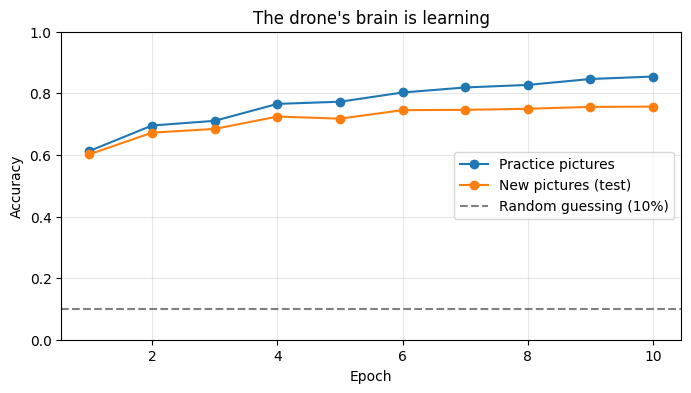

In [ ]:
plt.figure(figsize=(8, 4))                                                    # Drawing area for the progress chart.
epochs = range(1, len(history['test']) + 1)                                  # x-axis: epoch numbers.
plt.plot(epochs, history['train'], marker='o', label='Practice pictures')   # Accuracy on pictures it learned from.
plt.plot(epochs, history['test'],  marker='o', label='New pictures (test)') # Accuracy on never-seen pictures.
plt.axhline(0.10, ls='--', color='gray', label='Random guessing (10%)')     # Reference line.
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.ylim(0, 1)                 # Axis labels and range.
plt.title("The drone's brain is learning"); plt.legend(); plt.grid(alpha=0.3)
plt.show()                                                                   # Display it.

### 🔎 What to look for
- If the two lines stay **close together**, the model has learned general rules → it will work on new drone footage.
- If "practice" kept rising while "test" stayed flat, the model would be **memorising** instead of learning — like a student who memorises past exam answers but can't solve a new question.

---
## 5. How good is it?

### 5.1 Let's see it in action

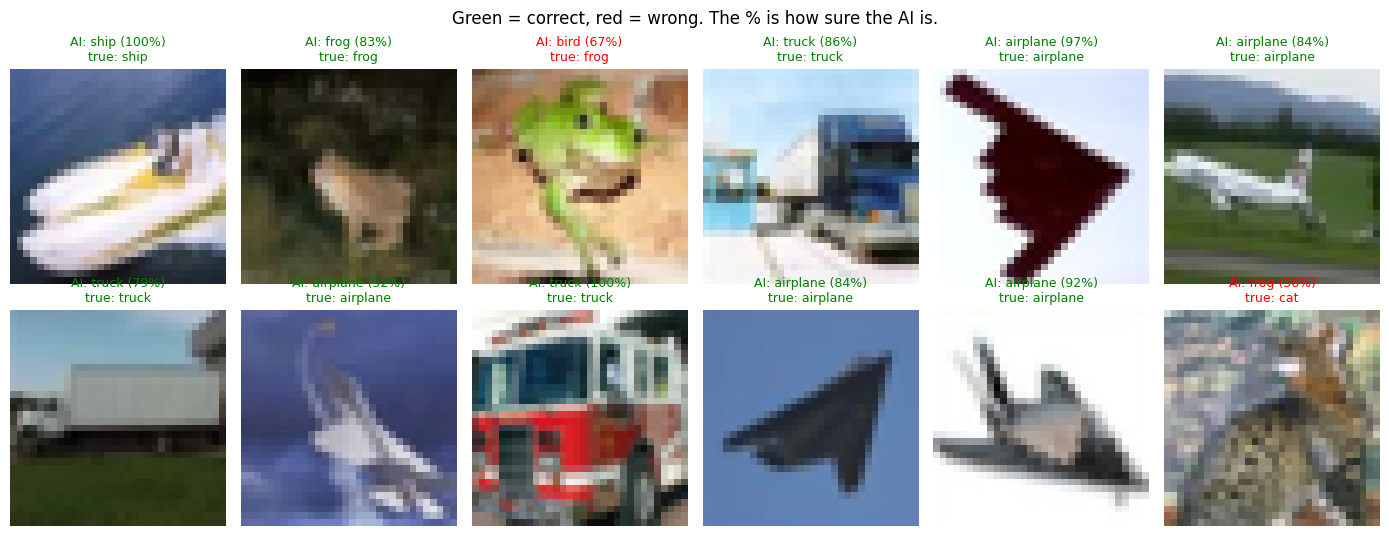

In [ ]:
model.eval()                                                  # Exam mode.
with torch.no_grad():                                         # No learning while testing.
    scores = torch.cat([model(X_test[i:i + 1000]) for i in range(0, len(y_test), 1000)])  # Scores for every test picture, 1,000 at a time.
    probs = F.softmax(scores, dim=1).cpu()                    # Turn scores into percentages that add up to 100%.
confidence, predicted = probs.max(1)                          # The model's top answer and how sure it is.
truth = y_test.cpu()                                          # The correct answers.

picks = np.random.default_rng(1).choice(len(truth), 12, replace=False)  # 12 random test pictures.
fig, axes = plt.subplots(2, 6, figsize=(14, 5.5))             # A 2×6 grid.
for ax, i in zip(axes.flat, picks):                           # For each chosen picture…
    right = predicted[i] == truth[i]                          # …was the model right?
    ax.imshow(show(X_test[i]))                                # Draw the picture.
    ax.set_title(f"AI: {CLASS_NAMES[predicted[i]]} ({confidence[i]:.0%})\ntrue: {CLASS_NAMES[truth[i]]}",
                 fontsize=9, color='green' if right else 'red')  # Green = correct, red = wrong.
    ax.axis('off')
plt.suptitle("Green = correct, red = wrong. The % is how sure the AI is.", fontsize=12)
plt.tight_layout(); plt.show()

### 🔎 What to look for
- Most answers are **green**. Look at the red ones — are they understandable mistakes (blurry, odd angle, unusual colour)?
- The **percentage** shows how sure the model is. Mistakes often come with **low confidence** — we'll use that in Section 6.

### 5.2 Which categories are easy, which are hard?

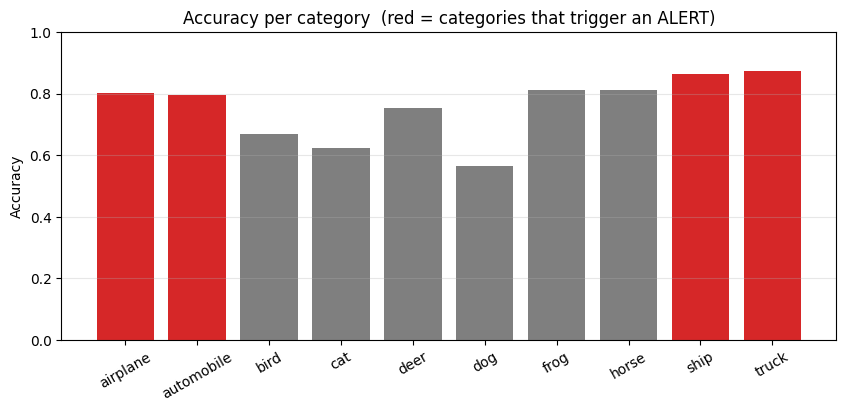

Top 5 mix-ups:
         dog mistaken for cat        223 times
  automobile mistaken for truck      130 times
         cat mistaken for dog        106 times
        bird mistaken for deer       96 times
         cat mistaken for bird       68 times


In [ ]:
per_class = [(predicted[truth == c] == c).float().mean().item() for c in range(10)]  # Accuracy for each category separately.
colours = ['tab:red' if DRONE_ACTION[n] == 'ALERT' else 'tab:gray' for n in CLASS_NAMES]  # Red bars = alert categories.

plt.figure(figsize=(10, 4))                                     # Drawing area.
plt.bar(CLASS_NAMES, per_class, color=colours)                  # One bar per category.
plt.ylabel("Accuracy"); plt.ylim(0, 1); plt.xticks(rotation=30)  # Labels.
plt.title("Accuracy per category  (red = categories that trigger an ALERT)")
plt.grid(axis='y', alpha=0.3); plt.show()

# The most common mix-ups.
mixups = {}                                                     # Count every (true, guessed) wrong pair.
for t, p in zip(truth.tolist(), predicted.tolist()):            # Go through every test picture.
    if t != p:                                                  # Only the mistakes.
        mixups[(t, p)] = mixups.get((t, p), 0) + 1               # Add one to that pair's count.
print("Top 5 mix-ups:")
for (t, p), n in sorted(mixups.items(), key=lambda kv: -kv[1])[:5]:  # Largest counts first.
    print(f"  {CLASS_NAMES[t]:>10} mistaken for {CLASS_NAMES[p]:<10} {n} times")

### 🔎 What to look for
- **Vehicles, ships and planes** (red bars) are usually recognised well; animals like **cats and dogs** are harder.
- The top mix-ups are usually **cat ↔ dog** and **automobile ↔ truck** — the same pairs a person might confuse in a tiny blurry picture.
- 💡 But think like the business: does mixing up a **car and a truck** matter? No — both trigger an ALERT anyway. Let's measure what really matters.

In [ ]:
should_alert = torch.tensor([DRONE_ACTION[CLASS_NAMES[t]] == 'ALERT' for t in truth.tolist()])     # What the right action was.
did_alert    = torch.tensor([DRONE_ACTION[CLASS_NAMES[p]] == 'ALERT' for p in predicted.tolist()]) # What the AI's answer leads to.

print(f"Correct category (10 choices)      : {(predicted == truth).float().mean():.1%}")
print(f"Correct ACTION (alert vs log)      : {(should_alert == did_alert).float().mean():.1%}")
print(f"Missed alerts  (real vehicle/ship/plane treated as animal) : {(should_alert & ~did_alert).sum().item()}")
print(f"False alarms   (animal treated as vehicle/ship/plane)      : {(~should_alert & did_alert).sum().item()}")

Correct category (10 choices)      : 75.7%
Correct ACTION (alert vs log)      : 95.3%
Missed alerts  (real vehicle/ship/plane treated as animal) : 231
False alarms   (animal treated as vehicle/ship/plane)      : 242


### 🔎 What to look for
- The model picks the **right action** much more often than the **exact category** — many "mistakes" are harmless for the business.
- **Missed alerts** and **false alarms** cost different things: a missed intruder may be a security risk, a false alarm wastes an operator's time. **Which one matters more is a business decision**, not an AI decision.

---
## 6. Field test: will it work on a real drone?  ⏱ 5 min

### 6.1 Bad flying conditions

The model learned from clean pictures. But drones fly in **fog**, at **dusk**, and they **shake**. Let's test the same model on the same test pictures, made worse.

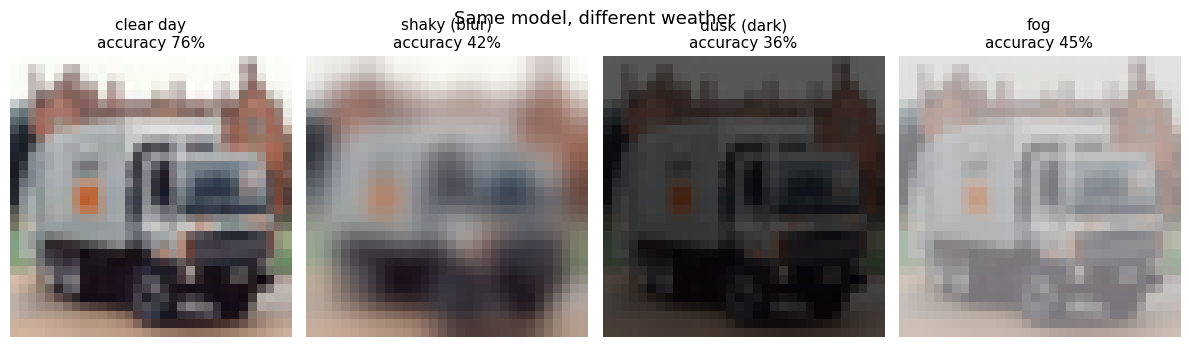

In [ ]:
def make_worse(pics, condition):                          # Simulate a bad flying condition on a batch of pictures.
    m, s = MEAN.to(pics.device), STD.to(pics.device)      # Average / spread values, on the same device as the pictures.
    p = pics * s + m                                      # Undo the centring → normal brightness 0–1.
    if condition == 'shaky (blur)':
        p = TF.gaussian_blur(p, kernel_size=5, sigma=1.5) # Smear each pixel over its neighbours, like camera shake.
    elif condition == 'dusk (dark)':
        p = p * 0.35                                      # Keep only 35% of the light.
    elif condition == 'fog':
        p = 0.45 * p + 0.55 * 0.8                         # Mix the picture with a light-grey haze.
    return (p.clamp(0, 1) - m) / s                        # Re-centre so the model gets numbers in the usual range.

conditions = ['clear day', 'shaky (blur)', 'dusk (dark)', 'fog']  # The scenarios we test.
results = {}                                              # Accuracy for each scenario.
for cond in conditions:
    pics = X_test if cond == 'clear day' else make_worse(X_test, cond)  # Apply the condition (or not).
    results[cond] = accuracy(model, pics, y_test)         # Re-run the exam.

example = X_test[(y_test == 9).nonzero()[0, 0]][None]     # One truck picture to show what each condition looks like.
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, cond in zip(axes, conditions):
    shown = example if cond == 'clear day' else make_worse(example, cond)  # Apply the condition.
    ax.imshow(show(shown[0])); ax.axis('off')
    ax.set_title(f"{cond}\naccuracy {results[cond]:.0%}", fontsize=11)    # Show the accuracy under it.
plt.suptitle("Same model, different weather", fontsize=13)
plt.tight_layout(); plt.show()

### 🔎 What to look for
- Accuracy **drops** in conditions the model never practised on — sometimes a lot.
- This is the **#1 reason AI that works in the lab fails in the field**.
- The fix is not a cleverer model, it is **better data**: include foggy, dark and shaky pictures in the training set (or simulate them, like we just did).

### 6.2 From a label to a decision

Remember the percentages from Section 5.1? We can use them as a safety rule:

- **Sure** (≥ 70%) and it's a vehicle/ship/plane → 🚨 **ALERT** the control room
- **Sure** and it's an animal → 📝 just **log** it
- **Not sure** (< 70%) → 👤 send the picture to a **human** to check

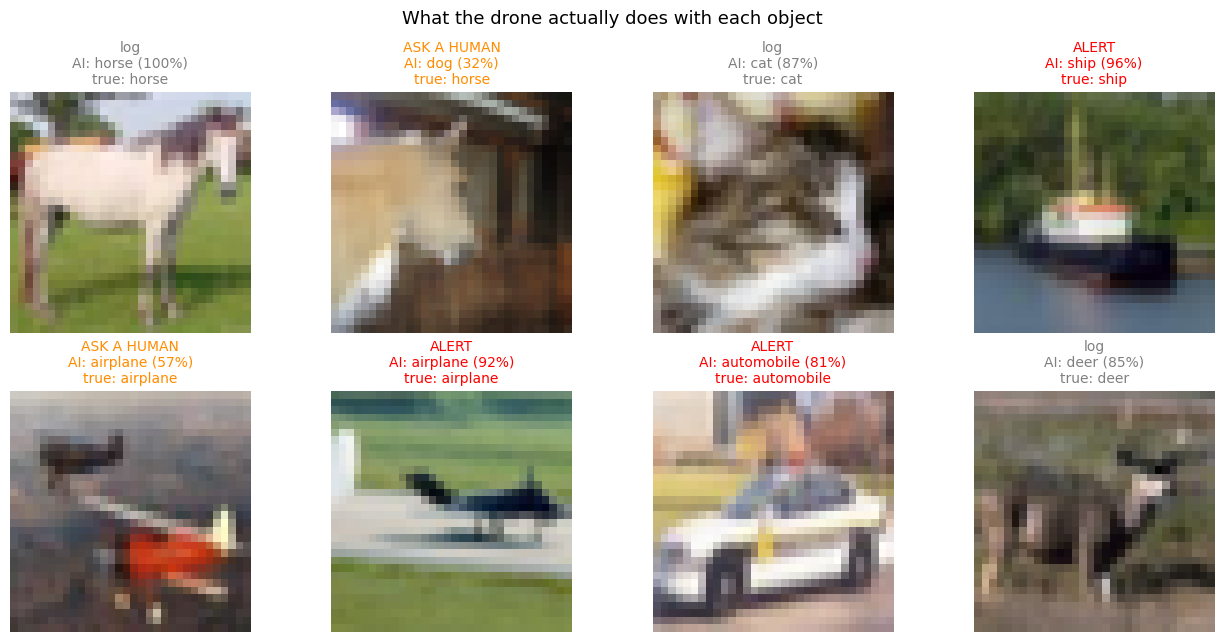

The drone decides alone on 65% of objects, and is right 90% of the time on those.
The other 35% go to a human.


In [ ]:
SURE_ENOUGH = 0.70                                         # Confidence needed before the drone acts on its own.

def drone_decides(i):                                      # What the drone does with test picture number i.
    name = CLASS_NAMES[predicted[i]]                       # The AI's answer, e.g. 'truck'.
    if confidence[i] < SURE_ENOUGH:                        # Not sure enough…
        return name, 'ASK A HUMAN'                         # …so a person takes a look.
    return name, 'ALERT' if DRONE_ACTION[name] == 'ALERT' else 'log'  # Sure → follow the business rule.

picks = np.random.default_rng(7).choice(len(truth), 8, replace=False)  # 8 objects "arriving" from the drone.
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, i in zip(axes.flat, picks):
    name, action = drone_decides(i)                        # Run the decision rule.
    colour = {'ALERT': 'red', 'log': 'gray', 'ASK A HUMAN': 'darkorange'}[action]  # Colour by action.
    ax.imshow(show(X_test[i])); ax.axis('off')
    ax.set_title(f"{action}\nAI: {name} ({confidence[i]:.0%})\ntrue: {CLASS_NAMES[truth[i]]}", fontsize=10, color=colour)
plt.suptitle("What the drone actually does with each object", fontsize=13)
plt.tight_layout(); plt.show()

sure = confidence >= SURE_ENOUGH                           # Pictures the drone decides on its own.
if sure.any():                                             # At least one picture passed the confidence bar.
    print(f"The drone decides alone on {sure.float().mean():.0%} of objects, "
          f"and is right {(predicted[sure] == truth[sure]).float().mean():.0%} of the time on those.")
    print(f"The other {(~sure).float().mean():.0%} go to a human.")
else:                                                      # The model is never that sure (e.g. trained too briefly).
    print("The model is never that sure yet — lower SURE_ENOUGH or train for more epochs.")

### 🔎 What to look for
- When the AI is **sure**, it is right **much more often** than its overall accuracy — the hard cases are handed to a person.
- `SURE_ENOUGH` is a **business knob**: raise it and the drone makes fewer mistakes but humans check more pictures. ✏️ *Try 0.5 and 0.9 and re-run.*
- This is how most real AI systems work: **AI handles the easy bulk, humans handle the hard cases.**

---
## 7. Wrap-up  ⏱ 1 min

| Today (classroom) | A real drone project |
|---|---|
| CIFAR-10 pictures | Your own drone pictures, labelled for your site and your categories |
| Classifier on ready-made cut-outs | A detector that finds the objects in the full frame first |
| Simulated fog / dusk / blur | Real flights in bad weather, added to the training data |
| One confidence rule | A review screen for humans, whose answers are used to retrain the model |

### 🎯 Key takeaways
1. **Start from the business question:** drone monitoring → recognise objects → classify each one.
2. **Pictures are numbers.** A CNN learns small filters that find edges, then shapes, then whole objects.
3. **Measure what matters to the business** (right *action*), not just raw accuracy.
4. **Field conditions and confidence rules** decide whether an AI system is ready to deploy.

### ✏️ Want to explore afterwards?
- Change `EPOCHS` to 20 — does accuracy keep improving?
- Add foggy pictures to training (use `make_worse` inside the training loop) and redo Section 6.1.
- Make `'bird'` an ALERT category (bird strikes are a real risk for drones!) and redo Section 5.2.